# Revenue Forecast — Full Pipeline v2

| Section | Nội dung |
|---|---|
| **00** | Setup & Config |
| **01** | Load, Split OLD/NEW, Drop leakage |
| **02** | Feature Engineering — OLD |
| **03** | Model OLD (LightGBM) + Đánh giá + SHAP |
| **04** | Feature Engineering — NEW |
| **05** | Intermediate Models: Stockout, Sessions, Bounce, AOV, Refund |
| **06** | Model NEW Revenue (aug features) + XGBoost so sánh |
| **07** | Đánh giá + SHAP |
| **08** | Ensemble OLD+NEW |
| **09** | Dự báo 2 năm → CSV |

**Insights tích hợp từ EDA:**
- `refund_lag1` → Revenue r=0.645 (leading indicator mạnh nhất)
- `stockout_lag1` → Revenue r=0.475
- Tháng 11 anomaly: `is_nov_promo` (Black Friday/11.11)
- Tháng 12 paradox: stockout cao nhưng revenue thấp
- KHÔNG dùng `refund_ratio` (quá ổn định) → dùng raw `total_refund_amount`
- Drop `log_sessions_x_conv`, `log_orders_x_aov` → dominant/multicollinearity

---
## 00 · Setup & Config

In [3]:
# !pip install lightgbm xgboost shap scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import xgboost as xgb
import shap

C_BLUE  = '#2563B0'
C_TEAL  = '#0D9488'
C_AMBER = '#D97706'
C_RED   = '#DC2626'
C_GRAY  = '#64748B'

# ── ĐỔI CÁC THÔNG SỐ NÀY ────────────────────────────────────────
DATA_PATH      = 'out.csv'
DATE_COL       = 'Date'
TARGET_REV     = 'Revenue'
TARGET_COGS    = 'COGS'
SPLIT_DATE     = '2012-12-31'
FORECAST_START = '2023-01-01'
FORECAST_END   = '2024-07-01'
OUTPUT_CSV     = 'forecast_revenue_cogs.csv'
# ────────────────────────────────────────────────────────────────
print('Config loaded OK')

Config loaded OK


---
## 01 · Load, Split OLD/NEW, Drop leakage

In [4]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df_raw = df_raw.sort_values(DATE_COL).reset_index(drop=True)

# Lưu COGS ratio để dự báo cuối
if TARGET_COGS in df_raw.columns:
    cogs_ratio = (df_raw[TARGET_COGS] / df_raw[TARGET_REV].replace(0, np.nan)).median()
    print(f'COGS/Revenue median ratio: {cogs_ratio:.4f}')
else:
    cogs_ratio = 0.72
    print(f'Khong tim thay cot COGS, dung fallback ratio: {cogs_ratio}')

LEAKAGE = ['COGS', 'total_payment_value']
dropped = [c for c in LEAKAGE if c in df_raw.columns]
df_raw  = df_raw.drop(columns=dropped)
print(f'Dropped leakage: {dropped}')
print(f'Rows: {len(df_raw):,} | {df_raw[DATE_COL].min().date()} -> {df_raw[DATE_COL].max().date()}')

COGS/Revenue median ratio: 0.8217
Dropped leakage: ['COGS', 'total_payment_value']
Rows: 3,833 | 2012-07-04 -> 2022-12-31


OLD: 181 rows | 2012-07-04 -> 2012-12-31
NEW: 3,652 rows | 2013-01-01 -> 2022-12-31


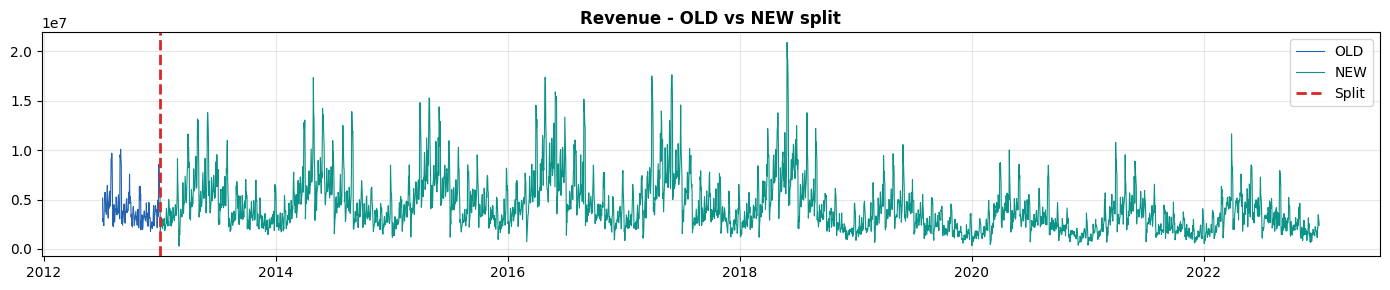

In [5]:
df_old = df_raw[df_raw[DATE_COL] <= SPLIT_DATE].copy().reset_index(drop=True)
df_new = df_raw[df_raw[DATE_COL] >  SPLIT_DATE].copy().reset_index(drop=True)

print(f'OLD: {len(df_old):,} rows | {df_old[DATE_COL].min().date()} -> {df_old[DATE_COL].max().date()}')
print(f'NEW: {len(df_new):,} rows | {df_new[DATE_COL].min().date()} -> {df_new[DATE_COL].max().date()}')

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df_old[DATE_COL], df_old[TARGET_REV], color=C_BLUE, lw=0.8, label='OLD')
ax.plot(df_new[DATE_COL], df_new[TARGET_REV], color=C_TEAL, lw=0.8, label='NEW')
ax.axvline(pd.Timestamp(SPLIT_DATE), color=C_RED, lw=2, ls='--', label='Split')
ax.set_title('Revenue - OLD vs NEW split', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 02 · Feature Engineering — OLD

In [6]:
OP_COLS_OLD = ['total_orders','total_items_sold','total_shipping_fee',
               'total_discount_given','total_refund_amount','total_returned_items',
               'avg_rating','total_reviews','total_stock_on_hand',
               'avg_fill_rate','total_stockout_days','return_rate','discount_ratio']
avail_op_old = [c for c in OP_COLS_OLD if c in df_old.columns]

def make_time_features(df):
    df = df.copy()
    df['month']     = df[DATE_COL].dt.month
    df['quarter']   = df[DATE_COL].dt.quarter
    df['dayofweek'] = df[DATE_COL].dt.dayofweek
    df['dayofyear'] = df[DATE_COL].dt.dayofyear
    df['year']      = df[DATE_COL].dt.year
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['dow_sin']   = np.sin(2*np.pi*df['dayofweek']/7)
    df['dow_cos']   = np.cos(2*np.pi*df['dayofweek']/7)
    df['doy_sin']   = np.sin(2*np.pi*df['dayofyear']/365)
    df['doy_cos']   = np.cos(2*np.pi*df['dayofyear']/365)
    df['is_q4']         = (df['quarter']==4).astype(int)
    df['is_q1']         = (df['quarter']==1).astype(int)
    df['is_weekend']    = (df['dayofweek']>=5).astype(int)
    df['is_tet_period'] = df['month'].isin([1,2]).astype(int)
    df['is_peak_month'] = df['month'].isin([4,12]).astype(int)
    df['is_summer']     = df['month'].isin([6,7,8]).astype(int)
    df['is_nov_promo']  = (df['month']==11).astype(int)
    df['is_dec_paradox']= (df['month']==12).astype(int)
    return df

def engineer_old(df):
    df = df.copy().sort_values(DATE_COL).reset_index(drop=True)
    df['log_revenue'] = np.log1p(df[TARGET_REV])
    df = make_time_features(df)
    df['days_from_start'] = (df[DATE_COL]-df[DATE_COL].min()).dt.days

    lr = df['log_revenue']
    for lag in [1, 7, 30]:
        df[f'lag_{lag}'] = lr.shift(lag)
    s = lr.shift(1)
    df['roll7_mean']  = s.rolling(7,  min_periods=3).mean()
    df['roll30_mean'] = s.rolling(30, min_periods=7).mean()
    df['roll7_std']   = s.rolling(7,  min_periods=3).std()
    df['momentum']    = df['roll7_mean'] - df['roll30_mean']

    for c in avail_op_old:
        df[f'log_{c}']  = np.log1p(df[c].clip(lower=0))
        df[f'{c}_lag1'] = df[c].shift(1)

    # ★ Leading indicators từ EDA
    if 'total_refund_amount' in df.columns:
        df['refund_lag1'] = df['total_refund_amount'].shift(1)
        df['refund_lag7'] = df['total_refund_amount'].shift(7)
    if 'total_stockout_days' in df.columns:
        df['stockout_lag1']  = df['total_stockout_days'].shift(1)
        df['stockout_ratio'] = (df['total_stockout_days']/(df[TARGET_REV]+1)*1e6).shift(1)

    if 'total_orders' in df.columns and 'total_items_sold' in df.columns:
        df['items_per_order'] = (df['total_items_sold']/(df['total_orders']+1)).shift(1)
    if 'avg_fill_rate' in df.columns:
        df['fill_rate_bin'] = pd.qcut(
            df['avg_fill_rate'].fillna(df['avg_fill_rate'].median()),
            q=3, labels=[0,1,2], duplicates='drop').astype(float)
    return df

df_old_fe = engineer_old(df_old)

EXCLUDE_OLD = [DATE_COL, TARGET_REV, 'log_revenue'] + avail_op_old
FEAT_OLD = [c for c in df_old_fe.columns
            if c not in EXCLUDE_OLD and df_old_fe[c].dtype != 'object']

df_old_model = df_old_fe[FEAT_OLD+['log_revenue',DATE_COL]].copy()

df_old_model = df_old_model.iloc[30:].reset_index(drop=True)

df_old_model = df_old_model.fillna(df_old_model.median(numeric_only=True))
X_old = df_old_model[FEAT_OLD]
y_old = df_old_model['log_revenue']
print(f'OLD features: {len(FEAT_OLD)} | X_old: {X_old.shape}')

OLD features: 69 | X_old: (151, 69)


---
## 03 · Model OLD + Đánh giá + SHAP

In [7]:
def calc_metrics(y_true_log, y_pred_log, label=''):
    rmse_l = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_l  = mean_absolute_error(y_true_log, y_pred_log)
    r2_l   = r2_score(y_true_log, y_pred_log)
    yt = np.expm1(y_true_log); yp = np.expm1(y_pred_log)
    return {'label':label,
            'RMSE_log':round(rmse_l,4), 'MAE_log':round(mae_l,4), 'R2_log':round(r2_l,4),
            'RMSE_orig':round(np.sqrt(mean_squared_error(yt,yp)),2),
            'MAE_orig':round(mean_absolute_error(yt,yp),2),
            'R2_orig':round(r2_score(yt,yp),4)}

def print_m(m):
    print(f"  {m['label']}")
    print(f"    Log  -> RMSE:{m['RMSE_log']:.4f} MAE:{m['MAE_log']:.4f} R2:{m['R2_log']:.4f}")
    print(f"    Orig -> RMSE:{m['RMSE_orig']:,.0f} MAE:{m['MAE_orig']:,.0f} R2:{m['R2_orig']:.4f}")

def cv_avg(mlist, name):
    print(f'\n-- {name} CV Average --')
    for k in ['RMSE_log','MAE_log','R2_log','R2_orig']:
        v=[m[k] for m in mlist]
        print(f'  {k:<12}: {np.mean(v):.4f} +/- {np.std(v):.4f}')

print('Helpers ready')

Helpers ready


In [8]:
tscv_old = TimeSeriesSplit(n_splits=3)
LGB_OLD  = dict(objective='regression', metric='rmse', n_estimators=500,
                learning_rate=0.03, num_leaves=31, max_depth=5,
                min_child_samples=10, feature_fraction=0.7,
                bagging_fraction=0.8, bagging_freq=5,
                reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1)

old_lgb_metrics=[]; old_lgb_oof=np.full(len(y_old),np.nan); old_lgb_models=[]

for fold,(tr,val) in enumerate(tscv_old.split(X_old)):
    Xtr,Xv = X_old.iloc[tr], X_old.iloc[val]
    ytr,yv = y_old.iloc[tr], y_old.iloc[val]
    mdl = lgb.LGBMRegressor(**LGB_OLD)
    mdl.fit(Xtr, ytr, eval_set=[(Xv,yv)],
            callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)])
    pred = mdl.predict(Xv)
    old_lgb_oof[val]=pred; old_lgb_models.append(mdl)
    m=calc_metrics(yv.values, pred, f'OLD LGB Fold {fold+1}')
    old_lgb_metrics.append(m); print_m(m)

cv_avg(old_lgb_metrics, 'OLD LightGBM')

  OLD LGB Fold 1
    Log  -> RMSE:0.1618 MAE:0.1239 R2:0.6290
    Orig -> RMSE:625,926 MAE:484,857 R2:0.6638
  OLD LGB Fold 2
    Log  -> RMSE:0.1402 MAE:0.0964 R2:0.7662
    Orig -> RMSE:479,808 MAE:335,367 R2:0.8012
  OLD LGB Fold 3
    Log  -> RMSE:0.3069 MAE:0.2686 R2:0.2951
    Orig -> RMSE:1,189,012 MAE:1,013,516 R2:0.3791

-- OLD LightGBM CV Average --
  RMSE_log    : 0.2030 +/- 0.0740
  MAE_log     : 0.1630 +/- 0.0755
  R2_log      : 0.5634 +/- 0.1978
  R2_orig     : 0.6147 +/- 0.1758


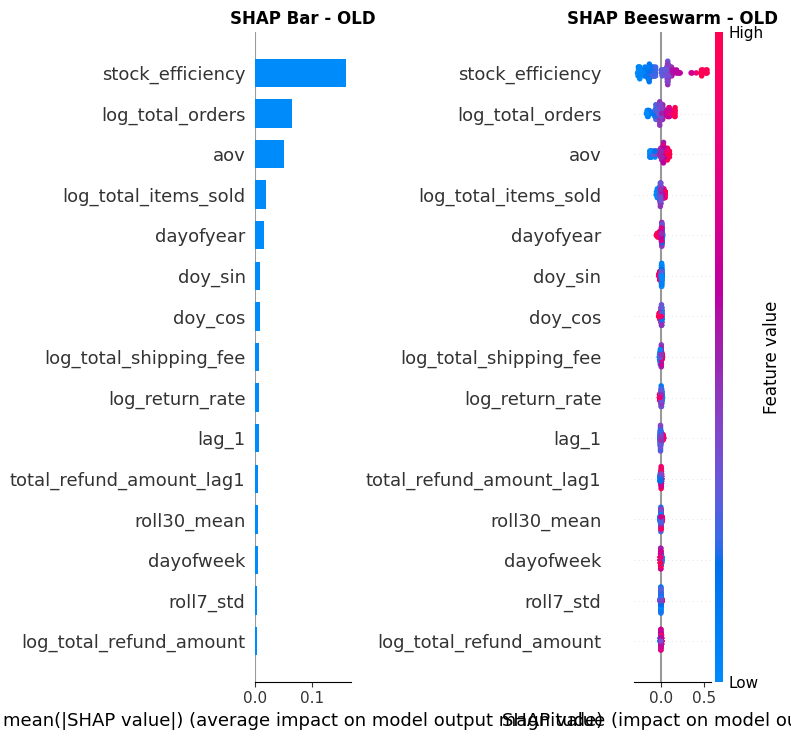

In [9]:
# Final OLD model + SHAP
best_old  = int(np.mean([m.best_iteration_ for m in old_lgb_models])*1.1)
final_old = lgb.LGBMRegressor(**{**LGB_OLD,'n_estimators':best_old}).fit(X_old, y_old)

exp_old = shap.TreeExplainer(final_old)
sv_old  = exp_old.shap_values(X_old)

fig, axes = plt.subplots(1,2, figsize=(16,6))
plt.sca(axes[0])
shap.summary_plot(sv_old, X_old, plot_type='bar', max_display=15, show=False)
axes[0].set_title('SHAP Bar - OLD', fontweight='bold')
plt.sca(axes[1])
shap.summary_plot(sv_old, X_old, max_display=15, show=False)
axes[1].set_title('SHAP Beeswarm - OLD', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 04 · Feature Engineering — NEW

**Không dùng:**
- `log_sessions_x_conv` — dominant feature (SHAP +1.21 vs others ~+0.03)
- `log_orders_x_aov` — redundant với revenue
- `refund_ratio` — quá ổn định (3.05%–3.22% trong 10 năm), likely computed từ revenue

In [10]:
WEB_COLS = ['total_sessions','total_page_views','avg_bounce_rate',
            'conversion_rate','aov','rev_per_session','new_customers']
OP_COLS_NEW = ['total_orders','total_items_sold','total_shipping_fee',
               'total_discount_given','total_refund_amount','total_returned_items',
               'avg_rating','total_reviews','total_stock_on_hand',
               'avg_fill_rate','total_stockout_days','return_rate','discount_ratio']

# Cột đã được engineer trong data gốc -> bỏ để tránh redundancy + dominance
SKIP_FROM_DATA = ['sessions_x_conv','stock_efficiency','price_effect','refund_ratio']

avail_web = [c for c in WEB_COLS    if c in df_new.columns]
avail_op  = [c for c in OP_COLS_NEW if c in df_new.columns]
print(f'Web : {avail_web}')
print(f'Op  : {avail_op}')

Web : ['total_sessions', 'total_page_views', 'avg_bounce_rate', 'conversion_rate', 'aov', 'rev_per_session', 'new_customers']
Op  : ['total_orders', 'total_items_sold', 'total_shipping_fee', 'total_discount_given', 'total_refund_amount', 'total_returned_items', 'avg_rating', 'total_reviews', 'total_stock_on_hand', 'avg_fill_rate', 'total_stockout_days', 'return_rate', 'discount_ratio']


In [11]:
def winsorize(s, lo=0.01, hi=0.99):
    l,h = s.quantile([lo,hi]); return s.clip(l,h)

def engineer_new(df):
    df = df.copy().sort_values(DATE_COL).reset_index(drop=True)
    df['log_revenue'] = np.log1p(df[TARGET_REV]) if TARGET_REV in df.columns else np.nan

    for c in ['return_rate','avg_bounce_rate','aov','conversion_rate']:
        if c in df.columns: df[c] = winsorize(df[c])

    df = make_time_features(df)
    df['days_from_start'] = (df[DATE_COL]-df[DATE_COL].min()).dt.days
    df['trend_post2016']  = np.where(df[DATE_COL]>'2016-12-31',
        (df[DATE_COL]-pd.Timestamp('2017-01-01')).dt.days.clip(0), 0)

    if 'log_revenue' in df.columns:
        lr = df['log_revenue']
        for lag in [1,7,14,30,365]: df[f'lag_{lag}'] = lr.shift(lag)
        s = lr.shift(1)
        df['roll7_mean']  = s.rolling(7,  min_periods=3).mean()
        df['roll14_mean'] = s.rolling(14, min_periods=5).mean()
        df['roll30_mean'] = s.rolling(30, min_periods=7).mean()
        df['roll7_std']   = s.rolling(7,  min_periods=3).std()
        df['momentum']    = df['roll7_mean'] - df['roll30_mean']

    for c in avail_web:
        df[f'log_{c}']  = np.log1p(df[c].clip(lower=0))
        df[f'{c}_lag1'] = df[c].shift(1)
    for c in avail_op:
        df[f'log_{c}']  = np.log1p(df[c].clip(lower=0))
        df[f'{c}_lag1'] = df[c].shift(1)

    # ★ Leading indicators (EDA insight)
    if 'total_refund_amount' in df.columns:
        df['refund_lag1']  = df['total_refund_amount'].shift(1)
        df['refund_lag7']  = df['total_refund_amount'].shift(7)
        df['refund_lag30'] = df['total_refund_amount'].shift(30)
    if 'total_stockout_days' in df.columns:
        df['stockout_lag1']  = df['total_stockout_days'].shift(1)
        df['stockout_ratio'] = (df['total_stockout_days']/(df[TARGET_REV]+1)*1e6).shift(1)                                if TARGET_REV in df.columns else np.nan

    # Derived
    if 'new_customers' in df.columns and 'total_sessions' in df.columns:
        df['new_cust_rate'] = (df['new_customers']/(df['total_sessions']+1)).shift(1)
    if 'total_discount_given' in df.columns and 'total_orders' in df.columns:
        df['discount_per_order'] = (df['total_discount_given']/(df['total_orders']+1)).shift(1)
    if 'discount_ratio' in df.columns:
        df['net_price_ratio'] = (1-df['discount_ratio']).shift(1)
    if 'avg_fill_rate' in df.columns:
        df['fill_rate_bin'] = pd.qcut(
            df['avg_fill_rate'].fillna(df['avg_fill_rate'].median()),
            q=3, labels=[0,1,2], duplicates='drop').astype(float)
    return df

df_new_fe = engineer_new(df_new)

# ★ Exclude redundant/dominant features
DROP_REDUNDANT = ['log_sessions_x_conv','sessions_x_conv_calc',
                  'log_orders_x_aov','orders_x_aov','refund_ratio']
EXCLUDE_NEW = ([DATE_COL, TARGET_REV, 'log_revenue']
               + avail_web + avail_op + SKIP_FROM_DATA + DROP_REDUNDANT)

FEAT_NEW = [c for c in df_new_fe.columns
            if c not in EXCLUDE_NEW and df_new_fe[c].dtype != 'object']

df_new_model = df_new_fe[FEAT_NEW+['log_revenue',DATE_COL]].dropna().reset_index(drop=True)
X_new = df_new_model[FEAT_NEW]
y_new = df_new_model['log_revenue']

print(f'NEW features: {len(FEAT_NEW)} | X_new: {X_new.shape}')
# Verify
bad = [c for c in DROP_REDUNDANT if c in X_new.columns]
print(f'Redundant still in X_new: {bad if bad else "none - OK"}')

NEW features: 80 | X_new: (3285, 80)
Redundant still in X_new: none - OK


---
## 05 · Intermediate Models

Dự báo **leading indicators** trước → dùng làm feature cho Revenue model.

| Target | Model | Lý do |
|---|---|---|
| `total_stockout_days` | LightGBM | r=0.475 với Revenue |
| `total_sessions` | LightGBM | Web traffic |
| `avg_bounce_rate` | Ridge | Ít variance |
| `aov` | LightGBM | Seasonal mạnh |
| `total_refund_amount` | LightGBM | r=0.645, leading indicator mạnh nhất |

In [12]:
def train_intermediate(df_src, target_col, extra_cols=None,
                       model_type='lgb', n_splits=3, label=''):

    if target_col not in df_src.columns:
        print(f'  SKIP: {target_col} not in data')
        return None, None, None

    df = df_src.copy().sort_values(DATE_COL).reset_index(drop=True)
    df = make_time_features(df)

    df['days_from_start'] = (df[DATE_COL]-df[DATE_COL].min()).dt.days
    df['trend_post2016']  = np.where(
        df[DATE_COL] > '2016-12-31',
        (df[DATE_COL] - pd.Timestamp('2017-01-01')).dt.days.clip(0),
        0
    )

    tgt = df[target_col]

    # ===== LAG FEATURES =====
    df['t_lag1']   = tgt.shift(1)
    df['t_lag7']   = tgt.shift(7)
    df['t_lag30']  = tgt.shift(30)
    df['t_lag365'] = tgt.shift(365)

    s = tgt.shift(1)
    df['t_roll7']    = s.rolling(7,  min_periods=3).mean()
    df['t_roll30']   = s.rolling(30, min_periods=7).mean()
    df['t_roll7std'] = s.rolling(7,  min_periods=3).std()

    # ===== EXTRA FEATURES (FIXED) =====
    extra = list(dict.fromkeys(extra_cols or []))  # remove duplicate
    ext_feats = []

    for c in extra:
        if c in df.columns and c != target_col:
            fname = f'x_{c}'
            df[fname] = df[c].shift(1)   # FIX: không dùng values
            ext_feats.append(fname)

    # ===== FEATURE LIST =====
    time_f = [
        'month_sin','month_cos','dow_sin','dow_cos','doy_sin','doy_cos',
        'is_q4','is_q1','is_weekend','is_tet_period','is_peak_month',
        'is_nov_promo','is_dec_paradox','days_from_start','trend_post2016'
    ]

    lag_f = [
        't_lag1','t_lag7','t_lag30','t_lag365',
        't_roll7','t_roll30','t_roll7std'
    ]

    feats = [f for f in (time_f + lag_f + ext_feats) if f in df.columns]

    # ===== FINAL DATA =====
    df_m = df[feats + [target_col]].dropna().reset_index(drop=True)

    Xm = df_m[feats]
    ym = df_m[target_col]

    # 🔥 FIX CHỐT: remove duplicate columns nếu có
    Xm = Xm.loc[:, ~Xm.columns.duplicated()]

    # ===== CV =====
    tscv = TimeSeriesSplit(n_splits=n_splits)
    oof  = np.full(len(ym), np.nan)
    mlist= []
    models=[]

    LGB_P = dict(
        objective='regression',
        metric='rmse',
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=5,
        min_child_samples=10,
        feature_fraction=0.8,
        random_state=42,
        verbose=-1
    )

    for fold,(tr,val) in enumerate(tscv.split(Xm)):
        Xtr, Xv = Xm.iloc[tr], Xm.iloc[val]
        ytr, yv = ym.iloc[tr], ym.iloc[val]

        if model_type == 'ridge':
            sc = StandardScaler()
            Xtr_s = sc.fit_transform(Xtr.fillna(Xtr.median()))
            Xv_s  = sc.transform(Xv.fillna(Xtr.median()))
            mdl   = Ridge(alpha=10).fit(Xtr_s, ytr)
            pred  = mdl.predict(Xv_s)

        else:
            mdl = lgb.LGBMRegressor(**LGB_P)
            mdl.fit(
                Xtr, ytr,
                eval_set=[(Xv, yv)],
                callbacks=[
                    lgb.early_stopping(30, verbose=False),
                    lgb.log_evaluation(-1)
                ]
            )
            pred = mdl.predict(Xv)

        oof[val] = pred
        models.append(mdl)

        mlist.append({
            'RMSE': np.sqrt(mean_squared_error(yv, pred)),
            'MAE': mean_absolute_error(yv, pred),
            'R2': r2_score(yv, pred)
        })

    # ===== FINAL MODEL =====
    if model_type == 'lgb':
        best_iters = [m.best_iteration_ for m in models if hasattr(m, 'best_iteration_')]
        bi = int(np.mean(best_iters) * 1.1) if best_iters else 100

        final = lgb.LGBMRegressor(**{**LGB_P, 'n_estimators': max(bi, 50)})
        final.fit(Xm, ym)

    else:
        sc = StandardScaler()
        final = Ridge(alpha=10).fit(sc.fit_transform(Xm.fillna(0)), ym)
        final._scaler = sc

    # ===== REPORT =====
    r2_avg   = np.mean([m['R2'] for m in mlist])
    rmse_avg = np.mean([m['RMSE'] for m in mlist])

    name = label or target_col
    print(f'  {name:<35} CV R2={r2_avg:.4f}  RMSE={rmse_avg:,.2f}')

    return final, oof, mlist

In [13]:
print('Training intermediate models...')
print('-'*60)

extra_common = ['total_orders','avg_fill_rate','total_stock_on_hand']

mdl_stockout, oof_stockout, m_stockout = train_intermediate(
    df_new, 'total_stockout_days', extra_common, label='Stockout days (r=0.475)')

mdl_sessions, oof_sessions, m_sessions = train_intermediate(
    df_new, 'total_sessions', extra_common, label='Sessions (web traffic)')

mdl_bounce, oof_bounce, m_bounce = train_intermediate(
    df_new, 'avg_bounce_rate', extra_common, model_type='ridge', label='Bounce rate (Ridge)')

mdl_aov, oof_aov, m_aov = train_intermediate(
    df_new, 'aov', extra_common, label='AOV (seasonal)')

mdl_refund, oof_refund, m_refund = train_intermediate(
    df_new, 'total_refund_amount',
    extra_common+['total_orders','total_discount_given'],
    label='Refund amount (leading r=0.645)')

print('-'*60)
print('All intermediate models trained')

Training intermediate models...
------------------------------------------------------------
  Stockout days (r=0.475)             CV R2=0.7783  RMSE=32.52
  Sessions (web traffic)              CV R2=0.8560  RMSE=3,450.26
  Bounce rate (Ridge)                 CV R2=-0.0653  RMSE=0.00
  AOV (seasonal)                      CV R2=0.5626  RMSE=3,442.11
  Refund amount (leading r=0.645)     CV R2=0.1149  RMSE=71,197.25
------------------------------------------------------------
All intermediate models trained


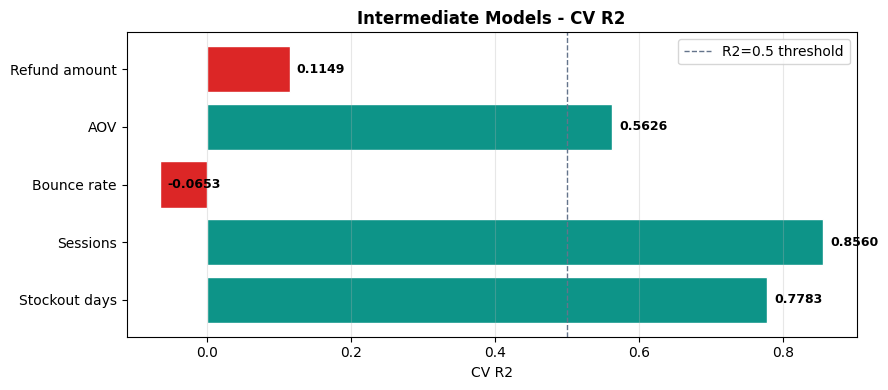

In [14]:
# Chart so sanh R2 intermediate models
inter_info = [
    ('Stockout days', m_stockout),
    ('Sessions',      m_sessions),
    ('Bounce rate',   m_bounce),
    ('AOV',           m_aov),
    ('Refund amount', m_refund),
]
labels = [x[0] for x in inter_info if x[1]]
r2s    = [np.mean([m['R2'] for m in x[1]]) for x in inter_info if x[1]]

fig, ax = plt.subplots(figsize=(9,4))
colors = [C_TEAL if v>0.5 else C_AMBER if v>0.2 else C_RED for v in r2s]
bars = ax.barh(labels, r2s, color=colors, edgecolor='white')
ax.axvline(0.5, color=C_GRAY, ls='--', lw=1, label='R2=0.5 threshold')
for b,v in zip(bars,r2s):
    ax.text(v+0.01, b.get_y()+b.get_height()/2, f'{v:.4f}',
            va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('CV R2'); ax.set_title('Intermediate Models - CV R2', fontweight='bold')
ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

---
## 06 · Model NEW — Revenue (augmented với intermediate predictions)

OOF (Out-of-Fold) predictions của intermediate models được dùng làm features.
OOF đảm bảo không có leakage vì dự báo ở fold N không dùng data của fold N.

In [15]:
# Ghep OOF predictions vao X_new
X_new_aug = X_new.copy()

# Align OOF bằng cách dùng length tối thiểu
n_new_model = len(df_new_model)

for col_name, oof_arr in [
    ('pred_stockout', oof_stockout),
    ('pred_sessions', oof_sessions),
    ('pred_bounce',   oof_bounce),
    ('pred_aov',      oof_aov),
    ('pred_refund',   oof_refund),
]:
    if oof_arr is None:
        X_new_aug[f'{col_name}_lag1'] = np.nan
        continue
    # Pad hoac trim ve dung do dai
    aligned = np.full(n_new_model, np.nan)
    n = min(len(oof_arr), n_new_model)
    aligned[:n] = oof_arr[:n]
    # Dung lag-1 de tranh leakage
    X_new_aug[f'{col_name}_lag1'] = pd.Series(aligned).shift(1).values

FEAT_NEW_AUG = X_new_aug.columns.tolist()

# Drop NaN do lag moi them
valid_mask = X_new_aug.notna().all(axis=1)
X_new_aug  = X_new_aug[valid_mask].reset_index(drop=True)
y_new_aug  = y_new[valid_mask].reset_index(drop=True)

print(f'X_new augmented: {X_new_aug.shape}')
aug_cols = [c for c in FEAT_NEW_AUG if 'pred_' in c]
print(f'Intermediate pred features added: {aug_cols}')

X_new augmented: (2460, 85)
Intermediate pred features added: ['pred_stockout_lag1', 'pred_sessions_lag1', 'pred_bounce_lag1', 'pred_aov_lag1', 'pred_refund_lag1']


In [16]:
# LightGBM NEW
tscv_new = TimeSeriesSplit(n_splits=5)
LGB_NEW  = dict(objective='regression', metric='rmse', n_estimators=1000,
                learning_rate=0.02, num_leaves=63, max_depth=-1,
                min_child_samples=20, feature_fraction=0.8,
                bagging_fraction=0.8, bagging_freq=5,
                reg_alpha=0.5, reg_lambda=1.0,
                random_state=42, verbose=-1)

new_lgb_metrics=[]; new_lgb_oof=np.full(len(y_new_aug),np.nan); new_lgb_models=[]

for fold,(tr,val) in enumerate(tscv_new.split(X_new_aug)):
    Xtr,Xv = X_new_aug.iloc[tr], X_new_aug.iloc[val]
    ytr,yv = y_new_aug.iloc[tr], y_new_aug.iloc[val]
    mdl = lgb.LGBMRegressor(**LGB_NEW)
    mdl.fit(Xtr.fillna(0), ytr, eval_set=[(Xv.fillna(0), yv)],
            callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)])
    pred = mdl.predict(Xv.fillna(0))
    new_lgb_oof[val]=pred; new_lgb_models.append(mdl)
    m=calc_metrics(yv.values, pred, f'LGB Fold {fold+1}')
    new_lgb_metrics.append(m); print_m(m)

cv_avg(new_lgb_metrics, 'NEW LightGBM (augmented)')

  LGB Fold 1
    Log  -> RMSE:0.1158 MAE:0.0777 R2:0.9571
    Orig -> RMSE:767,120 MAE:409,102 R2:0.9443
  LGB Fold 2
    Log  -> RMSE:0.0935 MAE:0.0585 R2:0.9657
    Orig -> RMSE:268,742 MAE:178,571 R2:0.9817
  LGB Fold 3
    Log  -> RMSE:0.1173 MAE:0.0588 R2:0.9521
    Orig -> RMSE:186,680 MAE:125,680 R2:0.9857
  LGB Fold 4
    Log  -> RMSE:0.0763 MAE:0.0456 R2:0.9813
    Orig -> RMSE:171,610 MAE:103,934 R2:0.9885
  LGB Fold 5
    Log  -> RMSE:0.0559 MAE:0.0360 R2:0.9897
    Orig -> RMSE:171,579 MAE:100,470 R2:0.9895

-- NEW LightGBM (augmented) CV Average --
  RMSE_log    : 0.0918 +/- 0.0235
  MAE_log     : 0.0553 +/- 0.0141
  R2_log      : 0.9692 +/- 0.0143
  R2_orig     : 0.9779 +/- 0.0170


In [17]:
# XGBoost NEW
XGB_NEW = dict(objective='reg:squarederror', n_estimators=1000, learning_rate=0.02,
               max_depth=6, min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
               reg_alpha=0.5, reg_lambda=1.0, random_state=42, verbosity=0,
               early_stopping_rounds=50)

new_xgb_metrics=[]; new_xgb_oof=np.full(len(y_new_aug),np.nan); new_xgb_models=[]

for fold,(tr,val) in enumerate(tscv_new.split(X_new_aug)):
    Xtr,Xv = X_new_aug.iloc[tr], X_new_aug.iloc[val]
    ytr,yv = y_new_aug.iloc[tr], y_new_aug.iloc[val]
    mdl = xgb.XGBRegressor(**XGB_NEW)
    mdl.fit(Xtr.fillna(0), ytr, eval_set=[(Xv.fillna(0),yv)], verbose=False)
    pred = mdl.predict(Xv.fillna(0))
    new_xgb_oof[val]=pred; new_xgb_models.append(mdl)
    m=calc_metrics(yv.values, pred, f'XGB Fold {fold+1}')
    new_xgb_metrics.append(m); print_m(m)

cv_avg(new_xgb_metrics, 'NEW XGBoost (augmented)')

  XGB Fold 1
    Log  -> RMSE:0.0972 MAE:0.0636 R2:0.9698
    Orig -> RMSE:632,961 MAE:331,424 R2:0.9621
  XGB Fold 2
    Log  -> RMSE:0.0839 MAE:0.0512 R2:0.9724
    Orig -> RMSE:265,682 MAE:166,678 R2:0.9821
  XGB Fold 3
    Log  -> RMSE:0.1113 MAE:0.0561 R2:0.9569
    Orig -> RMSE:181,513 MAE:121,546 R2:0.9865
  XGB Fold 4
    Log  -> RMSE:0.0557 MAE:0.0362 R2:0.9900
    Orig -> RMSE:144,394 MAE:86,490 R2:0.9918
  XGB Fold 5
    Log  -> RMSE:0.0451 MAE:0.0309 R2:0.9933
    Orig -> RMSE:159,563 MAE:90,828 R2:0.9909

-- NEW XGBoost (augmented) CV Average --
  RMSE_log    : 0.0786 +/- 0.0249
  MAE_log     : 0.0476 +/- 0.0122
  R2_log      : 0.9765 +/- 0.0135
  R2_orig     : 0.9827 +/- 0.0109


---
## 07 · Đánh giá tổng hợp + SHAP

In [18]:
# Bang so sanh tat ca models
rows=[]
for name,ml in [('OLD LGB', old_lgb_metrics),
                ('NEW LGB (aug)', new_lgb_metrics),
                ('NEW XGB (aug)', new_xgb_metrics)]:
    rows.append({'Model':name,
                 'RMSE_log':f"{np.mean([m['RMSE_log'] for m in ml]):.4f}",
                 'MAE_log' :f"{np.mean([m['MAE_log']  for m in ml]):.4f}",
                 'R2_log'  :f"{np.mean([m['R2_log']   for m in ml]):.4f}",
                 'R2_orig' :f"{np.mean([m['R2_orig']  for m in ml]):.4f}"})
print(pd.DataFrame(rows).set_index('Model').to_string())

              RMSE_log MAE_log  R2_log R2_orig
Model                                         
OLD LGB         0.2030  0.1630  0.5634  0.6147
NEW LGB (aug)   0.0918  0.0553  0.9692  0.9779
NEW XGB (aug)   0.0786  0.0476  0.9765  0.9827


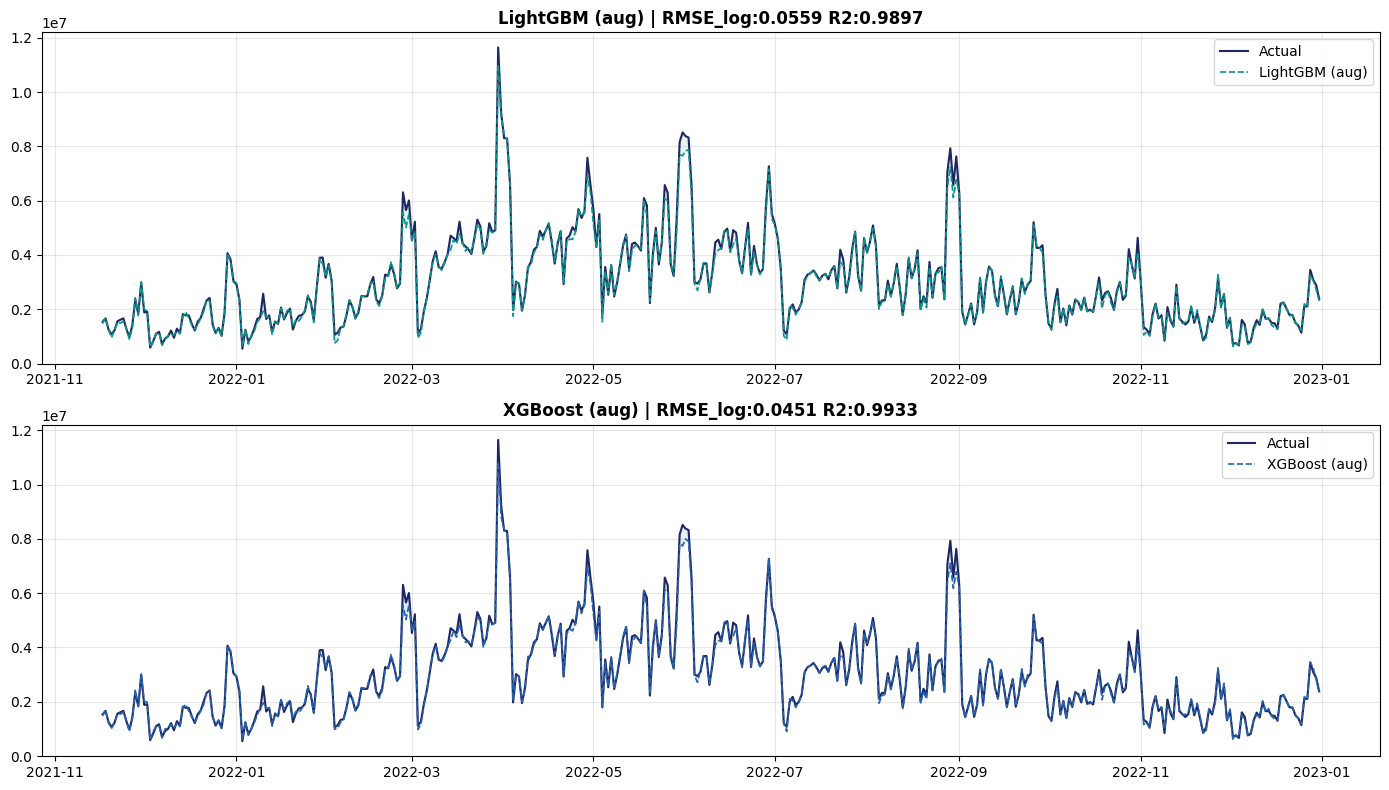

In [19]:
# Actual vs Predicted - fold cuoi NEW
last_val = list(tscv_new.split(X_new_aug))[-1][1]
dates_aug = df_new_model[DATE_COL][valid_mask].reset_index(drop=True)
dates_v   = dates_aug.iloc[last_val]
y_true_v  = y_new_aug.iloc[last_val]

fig, axes = plt.subplots(2,1, figsize=(14,8))
for ax, oof, name, color in [
    (axes[0], new_lgb_oof[last_val], 'LightGBM (aug)', C_TEAL),
    (axes[1], new_xgb_oof[last_val], 'XGBoost (aug)',  C_BLUE),
]:
    ax.plot(dates_v, np.expm1(y_true_v), color='#1E2761', lw=1.5, label='Actual')
    ax.plot(dates_v, np.expm1(oof), color=color, lw=1.2, ls='--', label=name)
    ax.fill_between(dates_v, np.expm1(y_true_v), np.expm1(oof), alpha=0.1, color=color)
    m = calc_metrics(y_true_v.values, oof, name)
    ax.set_title(f'{name} | RMSE_log:{m["RMSE_log"]:.4f} R2:{m["R2_log"]:.4f}', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout(); plt.show()

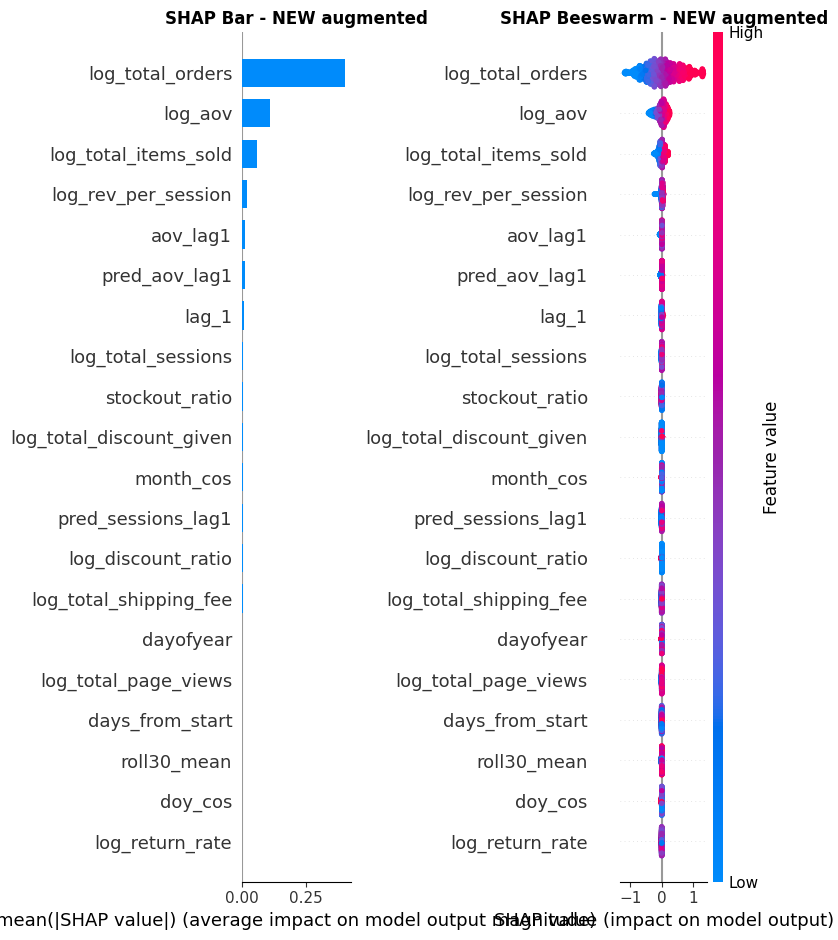

In [20]:
# SHAP - final NEW model
best_new  = int(np.mean([m.best_iteration_ for m in new_lgb_models])*1.1)
final_new = lgb.LGBMRegressor(**{**LGB_NEW,'n_estimators':best_new})
final_new.fit(X_new_aug.fillna(0), y_new_aug)

n_shap  = min(2000, len(X_new_aug))
X_shap  = X_new_aug.sample(n_shap, random_state=42).sort_index()
exp_new = shap.TreeExplainer(final_new)
sv_new  = exp_new.shap_values(X_shap.fillna(0))

fig, axes = plt.subplots(1,2, figsize=(16,7))
plt.sca(axes[0])
shap.summary_plot(sv_new, X_shap, plot_type='bar', max_display=20, show=False)
axes[0].set_title('SHAP Bar - NEW augmented', fontweight='bold')
plt.sca(axes[1])
shap.summary_plot(sv_new, X_shap, max_display=20, show=False)
axes[1].set_title('SHAP Beeswarm - NEW augmented', fontweight='bold')
plt.tight_layout(); plt.show()

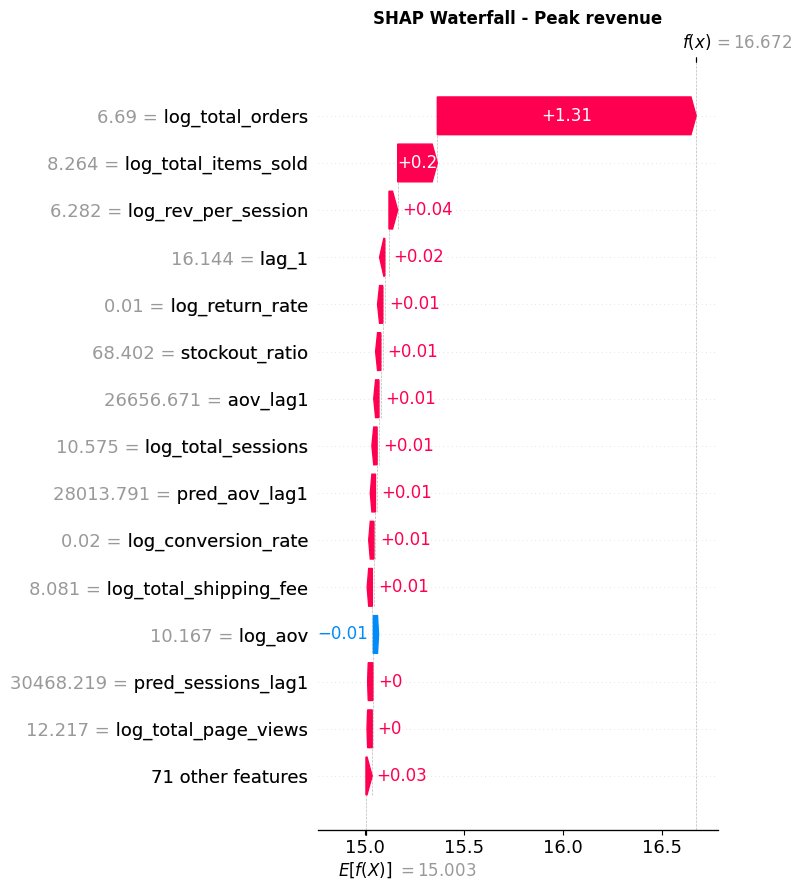

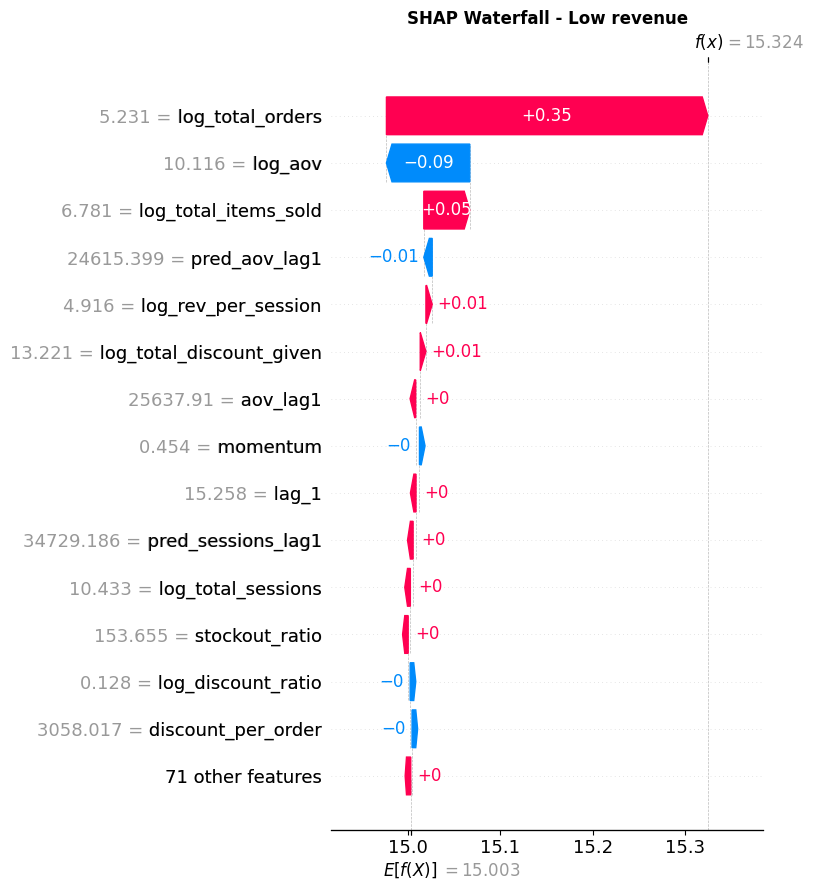

In [21]:
# SHAP Waterfall - ngay peak va low
for idx_label, get_idx in [
    ('Peak revenue', lambda: int(np.expm1(y_new_aug).argmax())),
    ('Low revenue',  lambda: int(np.expm1(y_new_aug).argmin())),
]:
    gi = get_idx()
    # Tim trong X_shap
    if gi in X_shap.index:
        si = X_shap.index.get_loc(gi)
    else:
        si = 0
    plt.figure(figsize=(10,6))
    shap.waterfall_plot(
        shap.Explanation(values=sv_new[si], base_values=exp_new.expected_value,
                         data=X_shap.iloc[si], feature_names=FEAT_NEW_AUG),
        max_display=15, show=False)
    plt.title(f'SHAP Waterfall - {idx_label}', fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 08 · Ensemble: LightGBM + XGBoost

Dùng **Stacking với meta-model Ridge** để học trọng số tối ưu.
OOF predictions được dùng để train meta-model → không bị overfit.

In [22]:
# Stacking meta-model
n = min(len(new_lgb_oof), len(new_xgb_oof))
valid = (~np.isnan(new_lgb_oof[:n])) & (~np.isnan(new_xgb_oof[:n]))

oof_stack  = np.column_stack([new_lgb_oof[:n][valid], new_xgb_oof[:n][valid]])
y_stack    = y_new_aug[:n].values[valid]

meta = Ridge(alpha=1.0).fit(oof_stack, y_stack)
w = np.clip(meta.coef_, 0, None)
w = w / w.sum()  # normalize
print(f'Ensemble weights: LGB={w[0]:.4f}  XGB={w[1]:.4f}')

oof_ens = w[0]*new_lgb_oof[:n][valid] + w[1]*new_xgb_oof[:n][valid]
m_ens = calc_metrics(y_stack, oof_ens, 'Ensemble (LGB+XGB)')
print('\nEnsemble CV:')
print_m(m_ens)

Ensemble weights: LGB=0.1052  XGB=0.8948

Ensemble CV:
  Ensemble (LGB+XGB)
    Log  -> RMSE:0.0828 MAE:0.0476 R2:0.9810
    Orig -> RMSE:335,200 MAE:159,694 R2:0.9798


In [23]:
# Final XGBoost NEW
best_xgb_iter = int(np.mean([
    m.best_iteration if hasattr(m,'best_iteration') else 500
    for m in new_xgb_models
])*1.1)

XGB_FINAL = {k:v for k,v in XGB_NEW.items() if k != 'early_stopping_rounds'}
XGB_FINAL['n_estimators'] = max(best_xgb_iter, 100)

final_xgb = xgb.XGBRegressor(**XGB_FINAL)
final_xgb.fit(X_new_aug.fillna(0), y_new_aug)
print('Final XGBoost trained')

Final XGBoost trained


---
## 09 · Dự báo 2 năm → CSV

**Chiến lược:**
1. Tạo date range 2 năm
2. Mỗi ngày: lấy lag từ historical data (và cập nhật sau mỗi dự báo)
3. Intermediate targets: dùng seasonal average từ historical
4. Ensemble (LGB+XGB) → Revenue
5. COGS = Revenue × cogs_ratio median lịch sử

In [24]:
# Seasonal averages tu historical data (dung cho intermediate targets)
df_new['month'] = df_new[DATE_COL].dt.month

def seas_avg(col, month_val):
    if col not in df_new.columns: return 0.0
    v = df_new[df_new['month']==month_val][col].median()
    return float(v) if not pd.isna(v) else 0.0

# Date range
fc_dates = pd.date_range(start=FORECAST_START, end=FORECAST_END, freq='D')
print(f'Forecast: {fc_dates[0].date()} -> {fc_dates[-1].date()} ({len(fc_dates)} days)')

# History log_revenue lookup
hist_log = df_new_fe.set_index(DATE_COL)['log_revenue'].to_dict()
print(f'Historical lookup: {len(hist_log)} dates available')

Forecast: 2023-01-01 -> 2024-07-01 (548 days)
Historical lookup: 3652 dates available


In [25]:
# ── CELL: Sửa rolling forecast - thay toàn bộ cell 09 forecast loop ──

revenue_fc = []
# Khởi tạo history cho tất cả features cần thiết
feat_history = {}
for col in avail_op + avail_web:
    if col in df_new.columns:
        feat_history[col] = df_new.set_index(DATE_COL)[col].to_dict()

for i, d in enumerate(fc_dates):
    month = d.month
    dow   = d.dayofweek

    # ── Hàm lấy lag revenue từ history (bao gồm cả predicted) ──
    def get_lag_rev(n):
        ld = d - pd.Timedelta(days=n)
        if ld in hist_log:
            return hist_log[ld]
        past = {k:v for k,v in hist_log.items() if k<=ld}
        return past[max(past)] if past else np.log1p(seas_avg(TARGET_REV, month))

    # ── Hàm lấy lag feature bất kỳ ──
    def get_lag_feat(col, n):
        ld = d - pd.Timedelta(days=n)
        h  = feat_history.get(col, {})
        if ld in h: return h[ld]
        past = {k:v for k,v in h.items() if k<=ld}
        return past[max(past)] if past else seas_avg(col, month)

    # Lag revenue
    lags = {f'lag_{n}': get_lag_rev(n) for n in [1,7,14,30,365]}

    # Rolling thực từ history (không phải seasonal avg)
    recent_vals = [get_lag_rev(n) for n in range(1, 31)]
    roll7_mean  = np.mean(recent_vals[:7])
    roll14_mean = np.mean(recent_vals[:14])
    roll30_mean = np.mean(recent_vals[:30])
    roll7_std   = np.std(recent_vals[:7])
    momentum    = roll7_mean - roll30_mean

    # Time features
    tf = {
        'month_sin': np.sin(2*np.pi*month/12),
        'month_cos': np.cos(2*np.pi*month/12),
        'dow_sin'  : np.sin(2*np.pi*dow/7),
        'dow_cos'  : np.cos(2*np.pi*dow/7),
        'doy_sin'  : np.sin(2*np.pi*d.dayofyear/365),
        'doy_cos'  : np.cos(2*np.pi*d.dayofyear/365),
        'is_q4'         : int(d.quarter==4),
        'is_q1'         : int(d.quarter==1),
        'is_weekend'    : int(dow>=5),
        'is_tet_period' : int(month in [1,2]),
        'is_peak_month' : int(month in [4,12]),
        'is_summer'     : int(month in [6,7,8]),
        'is_nov_promo'  : int(month==11),
        'is_dec_paradox': int(month==12),
        'days_from_start': (d - df_new[DATE_COL].min()).days,
        'trend_post2016' : max((d - pd.Timestamp('2017-01-01')).days, 0),
    }

    # ★ Dùng lag thực của từng feature, không phải seasonal avg
    op_web_feats = {}
    for c in avail_op + avail_web:
        lag1_val = get_lag_feat(c, 1)
        op_web_feats[f'log_{c}']  = np.log1p(max(lag1_val, 0))
        op_web_feats[f'{c}_lag1'] = lag1_val

    # Leading indicators — dùng lag thực
    refund_lag1   = get_lag_feat('total_refund_amount', 1)
    stockout_lag1 = get_lag_feat('total_stockout_days', 1)

    lead_feats = {
        'refund_lag1'   : refund_lag1,
        'refund_lag7'   : get_lag_feat('total_refund_amount', 7),
        'refund_lag30'  : get_lag_feat('total_refund_amount', 30),
        'stockout_lag1' : stockout_lag1,
        'stockout_ratio': stockout_lag1 / (np.expm1(lags['lag_1'])+1) * 1e6,
    }

    orders_l1  = get_lag_feat('total_orders', 1)
    session_l1 = get_lag_feat('total_sessions', 1)
    disc_l1    = get_lag_feat('total_discount_given', 1)
    disc_rat_l1= get_lag_feat('discount_ratio', 1)
    nc_l1      = get_lag_feat('new_customers', 1)

    derived = {
        'new_cust_rate'     : nc_l1 / (session_l1+1),
        'discount_per_order': disc_l1 / (orders_l1+1),
        'net_price_ratio'   : 1 - disc_rat_l1,
        'fill_rate_bin'     : 1.0,
        'momentum'          : momentum,
        'roll7_mean'        : roll7_mean,
        'roll14_mean'       : roll14_mean,
        'roll30_mean'       : roll30_mean,
        'roll7_std'         : roll7_std,
    }

    inter = {
        'pred_stockout_lag1': stockout_lag1,
        'pred_sessions_lag1': session_l1,
        'pred_bounce_lag1'  : get_lag_feat('avg_bounce_rate', 1),
        'pred_aov_lag1'     : get_lag_feat('aov', 1),
        'pred_refund_lag1'  : refund_lag1,
    }

    feat_row = {**lags, **tf, **op_web_feats, **lead_feats, **derived, **inter}
    feat_vec  = pd.DataFrame([feat_row]).reindex(columns=FEAT_NEW_AUG).fillna(0)

    p_lgb = final_new.predict(feat_vec)[0]
    p_xgb = final_xgb.predict(feat_vec)[0]
    p_ens = w[0]*p_lgb + w[1]*p_xgb

    rev = float(np.expm1(p_ens))
    revenue_fc.append({'date':d, 'revenue_forecast':rev, 'cogs_forecast':rev*cogs_ratio})

    # ★ Cập nhật CÙNG LÚC cả log_revenue lẫn các features vận hành
    hist_log[d] = p_ens
    # Propagate predicted operational features (dùng seasonal growth factor)
    for col in avail_op + avail_web:
        if col in feat_history:
            # Lấy giá trị cùng ngày năm ngoái từ history
            d_ly = d - pd.Timedelta(days=365)
            val_ly = feat_history[col].get(d_ly, seas_avg(col, month))
            # Giữ nguyên giá trị năm ngoái (yoy stable assumption)
            feat_history[col][d] = val_ly

    if (i+1) % 100 == 0:
        print(f'  {i+1}/{len(fc_dates)} done...')

print('Forecast complete!')

  100/548 done...
  200/548 done...
  300/548 done...
  400/548 done...
  500/548 done...
Forecast complete!


In [30]:
# Xuat CSV
df_fc = pd.DataFrame(revenue_fc)
df_fc['Date'] = df_fc['date'].dt.strftime('%Y-%m-%d')
df_fc['Revenue'] = df_fc['revenue_forecast'].round(2)
df_fc['COGS']    = df_fc['cogs_forecast'].round(2)
df_fc=df_fc.drop(columns=['revenue_forecast', 'cogs_forecast','date'])
df_fc.to_csv(OUTPUT_CSV, index=False)

print(f'Saved: {OUTPUT_CSV}')
print(f'Rows : {len(df_fc)}')
print('\nSample (first 10 rows):')
print(df_fc.head(10).to_string(index=False))

Saved: forecast_revenue_cogs.csv
Rows : 548

Sample (first 10 rows):
      Date    Revenue       COGS
2023-01-01 2418733.72 1987472.40
2023-01-02 2985273.91 2452998.21
2023-01-03 2450468.26 2013548.65
2023-01-04  574546.41  472104.52
2023-01-05 1280151.26 1051899.70
2023-01-06  802389.96  659323.47
2023-01-07 1053454.74  865623.27
2023-01-08 1281506.30 1053013.14
2023-01-09 1576930.10 1295762.74
2023-01-10 1741097.20 1430658.78


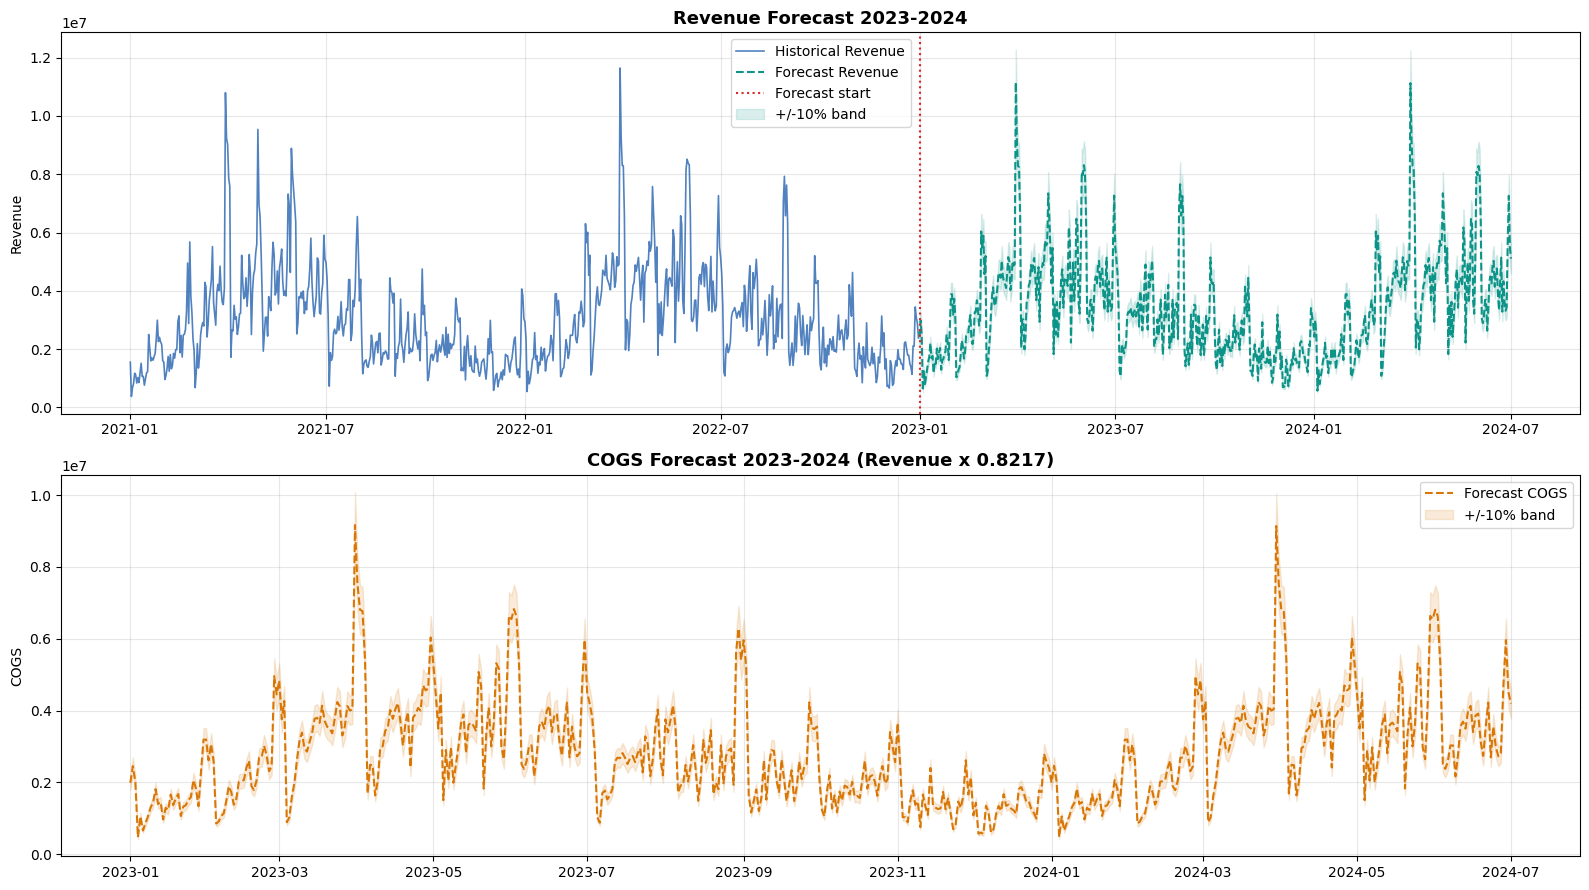


Monthly Summary:
                 Revenue          COGS
year_month                            
2023-01     5.895149e+07  4.844041e+07
2023-02     7.598936e+07  6.244042e+07
2023-03     1.333908e+08  1.096072e+08
2023-04     1.438556e+08  1.182061e+08
2023-05     1.362341e+08  1.119435e+08
2023-06     1.374154e+08  1.129142e+08
2023-07     9.891781e+07  8.128072e+07
2023-08     1.100343e+08  9.041517e+07
2023-09     9.059073e+07  7.443836e+07
2023-10     7.313225e+07  6.009274e+07
2023-11     5.555610e+07  4.565043e+07
2023-12     5.195434e+07  4.269086e+07
2024-01     5.897157e+07  4.845691e+07
2024-02     8.188923e+07  6.728834e+07
2024-03     1.366286e+08  1.122677e+08
2024-04     1.412020e+08  1.160256e+08
2024-05     1.377069e+08  1.131537e+08
2024-06     1.349196e+08  1.108634e+08
2024-07     5.104268e+06  4.194175e+06


In [27]:
# Visualize forecast
df_plot = pd.DataFrame(revenue_fc)
hist_plot = df_new[[DATE_COL,TARGET_REV]].tail(365*2)

fig, axes = plt.subplots(2,1, figsize=(16,9))

ax = axes[0]
ax.plot(hist_plot[DATE_COL], hist_plot[TARGET_REV],
        color=C_BLUE, lw=1.2, label='Historical Revenue', alpha=0.8)
ax.plot(df_plot['date'], df_plot['revenue_forecast'],
        color=C_TEAL, lw=1.5, ls='--', label='Forecast Revenue')
ax.axvline(pd.Timestamp(FORECAST_START), color=C_RED, lw=1.5, ls=':', label='Forecast start')
ax.fill_between(df_plot['date'],
                df_plot['revenue_forecast']*0.9,
                df_plot['revenue_forecast']*1.1,
                alpha=0.15, color=C_TEAL, label='+/-10% band')
ax.set_title('Revenue Forecast 2023-2024', fontweight='bold', fontsize=13)
ax.set_ylabel('Revenue'); ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax = axes[1]
ax.plot(df_plot['date'], df_plot['cogs_forecast'],
        color=C_AMBER, lw=1.5, ls='--', label='Forecast COGS')
ax.fill_between(df_plot['date'],
                df_plot['cogs_forecast']*0.9,
                df_plot['cogs_forecast']*1.1,
                alpha=0.15, color=C_AMBER, label='+/-10% band')
ax.set_title(f'COGS Forecast 2023-2024',
             fontweight='bold', fontsize=13)
ax.set_ylabel('COGS'); ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('forecast_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# Monthly summary
df_plot['year_month'] = pd.to_datetime(df_plot['date']).dt.to_period('M')
monthly = df_plot.groupby('year_month')[['revenue_forecast','cogs_forecast']].sum()
monthly.columns = ['Revenue','COGS']
print('\nMonthly Summary:')
print(monthly.to_string())

In [28]:
# Tong ket
print('='*65)
print('TONG KET PIPELINE v2')
print('='*65)

print('\n[OLD Model - LightGBM]')
for k in ['RMSE_log','MAE_log','R2_log']:
    v = [m[k] for m in old_lgb_metrics]
    print(f'  {k}: {np.mean(v):.4f} +/- {np.std(v):.4f}')

print('\n[NEW Model - Ensemble]')
m_final = calc_metrics(y_stack, oof_ens)
print(f'  RMSE_log : {m_final["RMSE_log"]}')
print(f'  MAE_log  : {m_final["MAE_log"]}')
print(f'  R2_log   : {m_final["R2_log"]}')
print(f'  Weights  : LGB={w[0]:.3f}  XGB={w[1]:.3f}')

print('\n[Intermediate Models]')
for name, ml in [('Stockout',m_stockout),('Sessions',m_sessions),
                  ('Bounce',m_bounce),('AOV',m_aov),('Refund',m_refund)]:
    if ml:
        print(f'  {name:<12}: R2={np.mean([m["R2"] for m in ml]):.4f}')

print(f'\n[Output]')
print(f'  File  : {OUTPUT_CSV}')
print(f'  Period: {FORECAST_START} -> {FORECAST_END}')
print(f'  Days  : {len(df_fc)}')
print(f'  COGS ratio: {cogs_ratio:.4f}')
print('='*65)

TONG KET PIPELINE v2

[OLD Model - LightGBM]
  RMSE_log: 0.2030 +/- 0.0740
  MAE_log: 0.1630 +/- 0.0755
  R2_log: 0.5634 +/- 0.1978

[NEW Model - Ensemble]
  RMSE_log : 0.0828
  MAE_log  : 0.0476
  R2_log   : 0.981
  Weights  : LGB=0.105  XGB=0.895

[Intermediate Models]
  Stockout    : R2=0.7783
  Sessions    : R2=0.8560
  Bounce      : R2=-0.0653
  AOV         : R2=0.5626
  Refund      : R2=0.1149

[Output]
  File  : forecast_revenue_cogs.csv
  Period: 2023-01-01 -> 2024-07-01
  Days  : 548
  COGS ratio: 0.8217
